In [1]:
# 1. 导入依赖
from copy import deepcopy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# 2. 设置随机种子，固定随机性
SEED = 713
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("PyTorch版本：", torch.__version__)
print("随机种子：", SEED)

PyTorch版本： 2.11.0+cu128
随机种子： 713


In [3]:
# 3. 生成二维二分类数据集

# 设置每个类别的样本数量
num_per_class = 120

# 创建一个独立的随机数生成器，并使用 SEED 设置随机种子
generator = torch.Generator().manual_seed(SEED)

# 生成类别 0 的样本：
# 1. torch.randn(num_per_class, 2) 生成 120 个二维标准正态分布样本
# 2. 乘以 0.70，控制样本的离散程度
# 3. 加上 [-1.0, -1.0]，将样本中心移动到坐标 (-1, -1) 附近
class_0 = (
    torch.randn(num_per_class, 2, generator=generator) * 0.70
    + torch.tensor([-1.0, -1.0])
)

# 生成类别 1 的样本：
# 生成方式与类别 0 相同，但样本中心被移动到坐标 (1, 1) 附近
class_1 = (
    torch.randn(num_per_class, 2, generator=generator) * 0.70
    + torch.tensor([1.0, 1.0])
)

# 沿第 0 维（样本维度）拼接两个类别的特征
# 拼接后的 features 形状为 [240, 2]：
# - 240 表示样本总数
# - 2 表示每个样本有两个特征
# float() 将数据类型统一转换为 torch.float32
features = torch.cat([class_0, class_1], dim=0).float()

# 为两个类别创建标签：
# - 类别 0 的 120 个样本对应标签 0
# - 类别 1 的 120 个样本对应标签 1
# 拼接后的 labels 形状为 [240]
# 二分类模型通常使用浮点型标签计算二元交叉熵损失
labels = torch.cat(
    [
        torch.zeros(num_per_class),
        torch.ones(num_per_class),
    ],
    dim=0,
).float()

# 输出特征张量的形状和数据类型
print("features: ", features.shape, features.dtype)

# 输出标签张量的形状和数据类型
print("labels: ", labels.shape, labels.dtype)

features:  torch.Size([240, 2]) torch.float32
labels:  torch.Size([240]) torch.float32


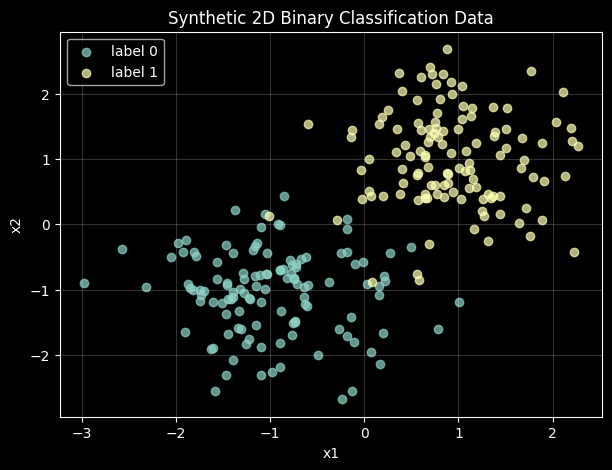

In [4]:
# 4. 画数据分布图
plt.figure(figsize=(7, 5))
plt.scatter(features[labels == 0, 0], features[labels == 0, 1], alpha=0.7, label="label 0")
plt.scatter(features[labels == 1, 0], features[labels == 1, 1], alpha=0.7, label="label 1")
plt.xlabel("x1"); plt.ylabel("x2")
plt.title("Synthetic 2D Binary Classification Data")
plt.legend(); plt.grid(alpha=0.2); plt.show()

In [5]:
# 5. 划分数据集
# 随机重排数据集
indices = torch.randperm(len(features), generator=torch.Generator().manual_seed(SEED))

# train : valid : test = 4 : 1 : 1
train_idx, valid_idx, test_idx = indices[:160], indices[160:200], indices[200:]
train_x, train_y = features[train_idx], labels[train_idx]
valid_x, valid_y = features[valid_idx], labels[valid_idx]
test_x, test_y = features[test_idx], labels[test_idx]
print("train / valid / test: ", len(train_x), len(valid_x), len(test_x))

train / valid / test:  160 40 40


In [6]:
# 6. Dataset → DataLoader → batch
# 设置batch大小
BATCH_SIZE = 16

# Dataset
train_set = TensorDataset(train_x, train_y)
valid_set = TensorDataset(valid_x, valid_y)
test_set = TensorDataset(test_x, test_y)

# DataLoader
# 训练集随机重排
train_loader = DataLoader(train_set, BATCH_SIZE, shuffle=True,
                          generator=torch.Generator().manual_seed(SEED))
valid_loader = DataLoader(valid_set, BATCH_SIZE)
test_loader = DataLoader(test_set, BATCH_SIZE)
print("训练集batch数量：", len(train_loader))

训练集batch数量： 10


In [7]:
# 7. 查看一个batch
preview_loader = DataLoader(train_set, BATCH_SIZE, shuffle=False)
batch_features, batch_labels = next(iter(preview_loader))
print("batch_features: ", batch_features.shape, batch_features.dtype)
print("batch_labels: ", batch_labels.shape, batch_labels.dtype)
print("第一条样本：", batch_features[0], "label=", batch_labels[0])

batch_features:  torch.Size([16, 2]) torch.float32
batch_labels:  torch.Size([16]) torch.float32
第一条样本： tensor([-0.0284,  0.3936]) label= tensor(1.)


In [8]:
# 8. 定义模型：[B, 2] → [B, 1] → [B]
# 使用线性回归模型
model = nn.Linear(in_features=2, out_features=1)

# 初始化权重
with torch.no_grad():
    model.weight.copy_(torch.tensor([[0.4, -0.2]]))
    model.bias.fill_(0.1)

# 将一批数据输入模型进行前向传播，获取输出的未归一化原始分数，并去掉输出里多余的维度，输出的维度应为1
logits = model(batch_features).squeeze(dim=1)
print("model: ", model)
print("logits: ", logits.shape, logits.dtype)

model:  Linear(in_features=2, out_features=1, bias=True)
logits:  torch.Size([16]) torch.float32


In [9]:
# 9. 定义损失函数和优化器
# 损失函数使用BCE
loss_fn = nn.BCEWithLogitsLoss()
loss = loss_fn(logits, batch_labels)
print("loss: ", loss.shape, loss.dtype)

# 优化器使用SGD，学习率为0.2
optimizer = torch.optim.SGD(model.parameters(), lr=0.2)

loss:  torch.Size([]) torch.float32


In [10]:
# 10. 执行一次更新
# 拷贝一份模型，用来测试
update_demo = deepcopy(model)
demo_optimizer = torch.optim.SGD(update_demo.parameters(), lr=0.2)
# 储存更新前的权重
before = update_demo.weight.detach().clone()

# 进行一次训练
# 清空累积的梯度
demo_optimizer.zero_grad()
# 前向传播计算损失
demo_loss = loss_fn(update_demo(batch_features).squeeze(1), batch_labels)
# 反向传播
demo_loss.backward()
# 梯度更新
demo_optimizer.step()

# 获取更新后的权重
after = update_demo.weight.detach().clone()
print("更新前：", before)
print("更新后：", after)
print("参数变化量：", (after-before).abs().sum().item())

更新前： tensor([[ 0.4000, -0.2000]])
更新后： tensor([[ 0.4655, -0.1073]])
参数变化量： 0.15816602110862732


In [11]:
# 11. 验证函数，返回平均损失和精确率
def evaluate(model, data_loader):
    # 切换为验证模式
    model.eval()
    total_loss, total_correct, total_count = 0.0, 0, 0
    with torch.no_grad():
        for x, y in data_loader:
            logits = model(x).squeeze(1)
            total_loss += loss_fn(logits, y).item() * len(y)
            # 预测值大于等于0.5为标签1，小于0.5为标签0
            predictions = (torch.sigmoid(logits) >= 0.5).float()
            total_correct += (predictions == y).sum().item()
            total_count += len(y)
    return total_loss / total_count, total_correct / total_count


In [12]:
# 12. 训练一个epoch，返回平均损失
def train_one_epoch(model, data_loader, optimizer):
    # 切换为训练模式
    model.train()
    total_loss, total_count = 0.0, 0
    for x, y in data_loader:
        # 梯度清零
        optimizer.zero_grad()
        # 挤压成一维向量
        logits = model(x).squeeze(1)
        # 前向传播计算损失
        loss = loss_fn(logits, y)
        # 反向传播损失
        loss.backward()
        # 更新权重
        optimizer.step()
        total_loss += loss.item() * len(y)
        total_count += len(y)
    return total_loss / total_count

In [13]:
# 13. 完整训练，根据验证集的loss选择更优的模型权重
# 记录训练过程，最佳模型权重，最佳验证集loss
history, best_state, best_valid_loss = [], None, float("inf")

# 训练30个epoch
for epoch in range(1, 31):
    train_loss = train_one_epoch(model, train_loader, optimizer)
    valid_loss, valid_acc = evaluate(model, valid_loader)
    history.append({"epoch": epoch, "train_loss": train_loss,
                    "valid_loss": valid_loss, "valid_acc": valid_acc})
    if valid_loss < best_valid_loss:
        best_valid_loss, best_state = valid_loss, deepcopy(model.state_dict())
    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:02d} | train {train_loss:.4f} | "
              f"valid {valid_loss:.4f} | acc {valid_acc:.3f}")

history = pd.DataFrame(history)

Epoch 01 | train 0.4182 | valid 0.2287 | acc 0.975
Epoch 05 | train 0.1399 | valid 0.0851 | acc 0.975
Epoch 10 | train 0.1064 | valid 0.0606 | acc 0.975
Epoch 15 | train 0.0947 | valid 0.0521 | acc 0.975
Epoch 20 | train 0.0887 | valid 0.0479 | acc 0.975
Epoch 25 | train 0.0851 | valid 0.0455 | acc 0.975
Epoch 30 | train 0.0827 | valid 0.0440 | acc 0.975


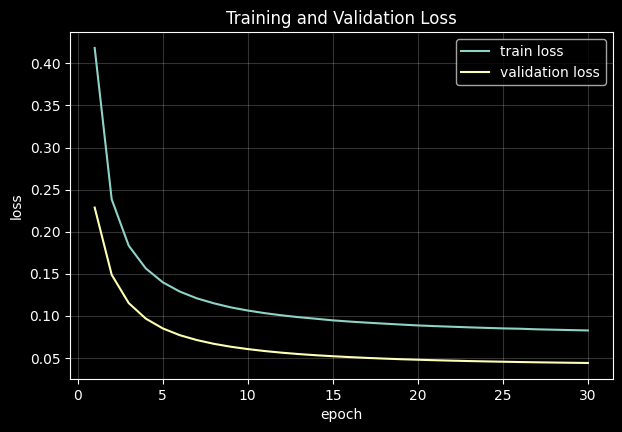

,epoch,train_loss,valid_loss,valid_acc
25,26,0.084725,0.045165,0.975
26,27,0.084021,0.044845,0.975
27,28,0.083561,0.044559,0.975
28,29,0.083111,0.044294,0.975
29,30,0.082680,0.044049,0.975


In [14]:
# 14. 画出训练与验证loss
plt.figure(figsize=(7, 4.5))
plt.plot(history["epoch"], history["train_loss"], label="train loss")
plt.plot(history["epoch"], history["valid_loss"], label="validation loss")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("Training and Validation Loss")
plt.legend(); plt.grid(alpha=0.2); plt.show()

history.tail()

In [15]:
# 15. 恢复最佳验证模型，最后检查test集
best_epoch = int(history.loc[history["valid_loss"].idxmin(), "epoch"])
model.load_state_dict(best_state)
test_loss, test_acc = evaluate(model, test_loader)

print("最佳验证epoch：", best_epoch)
print("最佳验证loss：", round(best_valid_loss, 4))
print("最终test loss：", round(test_loss, 4))
print("最终test accuracy：", round(test_acc, 3))

最佳验证epoch： 30
最佳验证loss： 0.044
最终test loss： 0.058
最终test accuracy： 1.0


In [16]:
# 16. 用shape表复述完整数据流
shape_table = pd.DataFrame([
    ["全部输入", "features", tuple(features.shape)],
    ["一个batch", "batch_features", tuple(batch_features.shape)],
    ["模型输出", "logits", tuple(model(batch_features).squeeze(1).shape)],
    ["真实标签", "batch_labels", tuple(batch_labels.shape)],
    ["批次损失", "loss", tuple(loss.shape)],
], columns=["阶段", "变量", "shape"])
shape_table

,阶段,变量,shape
0,全部输入,features,"(240, 2)"
1,一个batch,batch_features,"(16, 2)"
2,模型输出,logits,"(16,)"
3,真实标签,batch_labels,"(16,)"
4,批次损失,loss,()
